# Feature Engineering 

It is a technique of machine learning which helps us to create new features or transforming the existing feature to make the data more informative for machine learning model

In this we have Four steps:-
1. Feature Transformation
2. Feature Construction
3. Feature Selection
4. Feature Extraction

## 1. Feature Transformation
It is a part of feature engineering in this we transform the feature from original feature without changing the original information. It improves the performance of ml model while training.
* It also have 4 parts:-
1. Feature Scaling
2. Outlier Detection
3. Handling Categorical Variables
4. Missing Value imputation

### 1.1 Feature Scaling
It is technique which transform the feature where mean is 0 and standard deviation is 1. ( Ye datapoint ko center me lekar aata hai jiska mean = 0 and std = 1 hoga)
- We have diff. type of scaling 
1. Standardization (Z-Score)
2. Noramalization (MinMax Scaler)
3. MeanAbs Scaling
4. Robust Scaling

In [12]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
print("Imp Libarary are imported!!")

Imp Libarary are imported!!


In [29]:
# Take Example of Age Column of titanic dataset
df = pd.read_csv("social_network_ads.csv")
print("DataFrame Loaded")

DataFrame Loaded


In [ ]:
df.head()
# Purchased 0 = NO 1= YES

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


#### Before Scaling

<Axes: xlabel='Age', ylabel='count'>

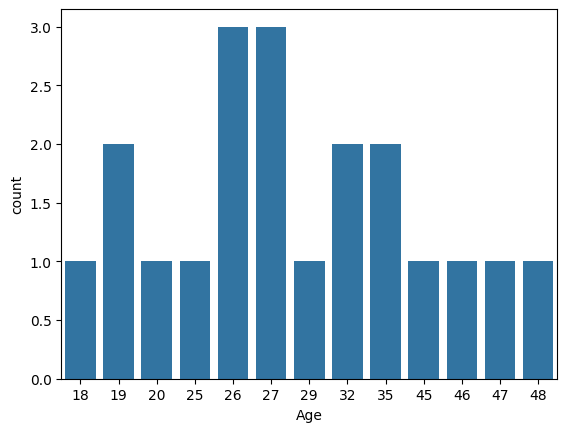

In [ ]:
df.head()
sns.countplot(x = df['Age'].head(20))

<Axes: xlabel='Age', ylabel='EstimatedSalary'>

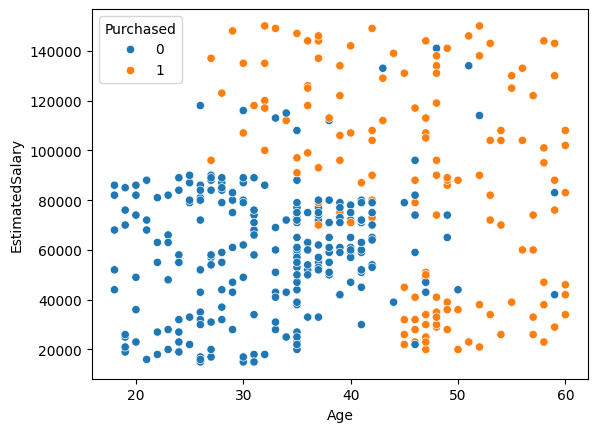

In [33]:
sns.scatterplot(x=df["Age"], y = df['EstimatedSalary'], hue = df['Purchased'])

## We perfom scaling after train_test_split but now for practice we only check here it working..

#### a) Standard Scaler

In [ ]:
scaler = StandardScaler()
# df['Age_Scaled'] = scaler.fit_transform(df[['Age']])
# df['EstimatedSalary_Scaled'] = scaler.fit_transform(df[['EstimatedSalary']])

#### After Scaling 

In [37]:
df.head()

,Age,EstimatedSalary,Purchased,Age_Scaled,EstimatedSalary_Scaled
0,19,19000,0,-1.781797,-1.490046
1,35,20000,0,-0.253587,-1.460681
2,26,43000,0,-1.113206,-0.785290
3,27,57000,0,-1.017692,-0.374182
4,19,76000,0,-1.781797,0.183751


Text(0.5, 1.0, 'After Scaling')

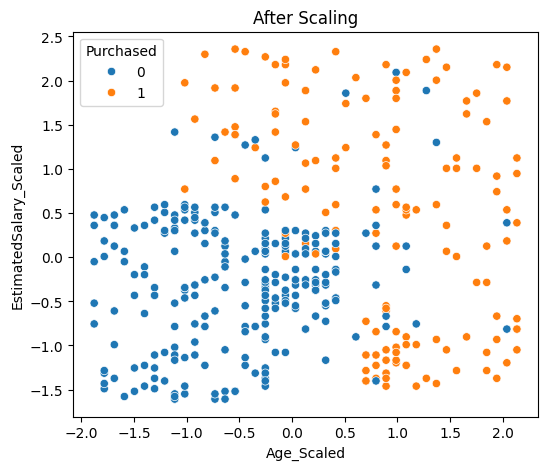

In [39]:
fig = plt.figure(figsize=(6,5))
sns.scatterplot(x=df["Age_Scaled"], y = df['EstimatedSalary_Scaled'], hue = df['Purchased'])
plt.title("After Scaling")


After Scaling u can see the data will digest under -2.5 to 2.5 ("Estimated Salary") and -2.0 to 2.0 ("Age"), but the distribution of data remains same.Befoe scaling our salary in thousands now 0.5, 1.0 etc. It's good for algo which is scale sensitive and improve the performance

#### b) Normalization (MinMax Scaler)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['Age_Scaled'] = scaler.fit_transform(df[['Age']])
df['EstimatedSalary_Scaled'] = scaler.fit_transform(df[['EstimatedSalary']])

#Formula:- x' = x - xmin/xmax - xmin

In [41]:
df.head()

,Age,EstimatedSalary,Purchased,Age_Scaled,EstimatedSalary_Scaled
0,19,19000,0,0.023810,0.029630
1,35,20000,0,0.404762,0.037037
2,26,43000,0,0.190476,0.207407
3,27,57000,0,0.214286,0.311111
4,19,76000,0,0.023810,0.451852


Text(0.5, 1.0, 'After Scaling')

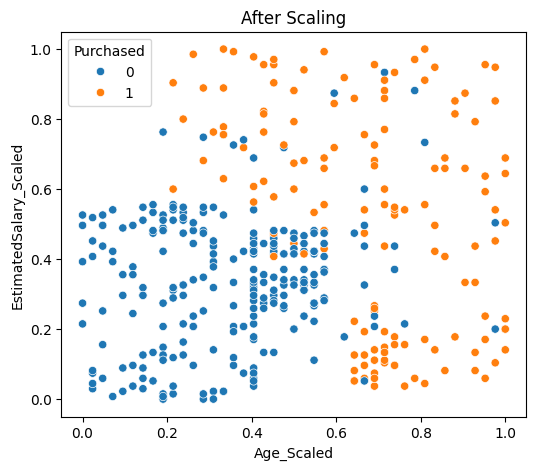

In [ ]:
fig = plt.figure(figsize=(6,5))
sns.scatterplot(x=df["Age_Scaled"], y = df['EstimatedSalary_Scaled'], hue = df['Purchased'])
plt.title("After Scaling")



In this Normalization data is squizzed between in range [0,1] like a cuboid container.You can see without scaling salary in thousand now in 0-1 range and age also it is diff from standard scaler here range is fixed. where not in standard scaler we convert the data into cetrical data
* Where we know the min and max of numerical data here it is apply before it ask himself the feature need scaling or not.


#### c) Robust Scaling

In [43]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df['Age_Scaled'] = scaler.fit_transform(df[['Age']])
df['EstimatedSalary_Scaled'] = scaler.fit_transform(df[['EstimatedSalary']])

Text(0.5, 1.0, 'After Scaling')

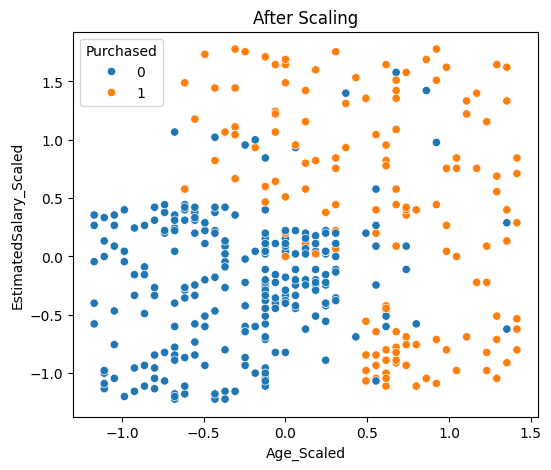

In [44]:
fig = plt.figure(figsize=(6,5))
sns.scatterplot(x=df["Age_Scaled"], y = df['EstimatedSalary_Scaled'], hue = df['Purchased'])
plt.title("After Scaling")



When our data has outliers then we apply Robust Scaler 
- Formula:- x' = x - median/IQR

# 1.2 Handling Categorical Values
In this we transform the categorical values into numerical values because ml model works on number it doesn't understand the string. In Encoding Categorical we have two types:-
1. Nominal:- In this type, dataset have input columns which inlcude only categories, here oreder are not important like ex-> gender ( male, female), purchase (yes, no). Here order does not matter. We can handle this type column with OneHot Encoder class of sklearn
2. Ordinal:- In this type, data have inpute columns which include categories with the priority order, like ex-> education(postgraduate, highschool, undergraduate etc) in education we have order like pg>ug>hs, pg have high priority, hg have less priority then pg and school have low priority all of them. We can handle this type column using OrdinalEncoder class of sklearn.
* For Output variable we use LabelEncoder for the target variable. Ex-> purchase, we know it is nominal category column but according to rule we use for this target column Only LabelEncoder Always.

### Ordinal Encoder & Label Encoder

In [5]:
# First we import all important library
import numpy as np
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
print("Library imported")


Library imported


In [2]:
#Load Dataset
df = pd.read_csv("Employee.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


In [16]:
df.head(20)

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
5,Bachelors,2016,Bangalore,3,22,Male,No,0,0
6,Bachelors,2015,New Delhi,3,38,Male,No,0,0
7,Bachelors,2016,Bangalore,3,34,Female,No,2,1
8,Bachelors,2016,Pune,3,23,Male,No,1,0
9,Masters,2017,New Delhi,2,37,Male,No,2,0


In this dataset we have Education column which is ordinal. Now we apply ordinal encoding

In [ ]:
# Now we perform the train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,0:1],df.iloc[:,-1], test_size=0.2)

3847    0
3549    0
2244    0
2773    0
4623    0
       ..
2923    1
1084    0
719     0
4361    0
3688    1
Name: LeaveOrNot, Length: 931, dtype: int64


In [26]:
X_train

array([[1.],
       [0.],
       [1.],
       ...,
       [0.],
       [0.],
       [1.]], shape=(3722, 1))

In [19]:
# Initialize the Ordinal Encoder object 
oe = OrdinalEncoder(categories=[['Bachelors','Masters','PHD']])
oe.fit(X_train)

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.","[['Bachelors', 'Masters', ...]]"
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'error'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",None
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide <encoder_infrequent_categories>`.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequentcategories, `max_categories` includes the category representing theinfrequent categories along with the frequent categories. If `None`,there is no limit to the number of output features.`max_categories` do **not** take into account missing or unknowncategories. Setting `unknown_value` or `encoded_missing_value` to aninteger will increase the number of unique integer codes by one each.This can result in up to `max_categories + 2` integer codes... versionadded:: 1.3 Read more in the :ref:`User Guide <encoder_infrequent_categories>`.",None
Name,Type,Value
categories_ categories_: list of arraysThe categories of each feature determined during ``fit`` (in order ofthe features in X and corresponding with the output of ``transform``).This does not include categories that weren't seen during ``fit``.,list,[array(['Bache... dtype=object)]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Education']
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 1.0,int,1


In [ ]:
X_train = oe.transform(X_train)
X_test = oe.transform(X_test)

In [27]:
oe.categories_

[array(['Bachelors', 'Masters', 'PHD'], dtype=object)]

In [23]:
print(X_train)

[[1.]
 [0.]
 [1.]
 ...
 [0.]
 [0.]
 [1.]]


In [25]:
print(X_test)

[[0.]
 [1.]
 [0.]
 [0.]
 [2.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [2.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [2.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [2.]
 [0.]
 [2.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [2.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [0.]
 [2.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.

### One Hot Encoder

In [28]:
df.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [63]:
X_train,X_test,y_train,y_test = train_test_split(df[['City','Gender','Age','JoiningYear']],df.iloc[:,-1], test_size=0.2)
print(X_train.shape,X_test.shape,y_train.shape, y_test.shape)

(3722, 4) (931, 4) (3722,) (931,)


In [64]:
X_train

,City,Gender,Age,JoiningYear
3238,Pune,Female,41,2017
4222,New Delhi,Male,27,2017
2435,Pune,Female,27,2013
1805,New Delhi,Male,26,2014
1646,Bangalore,Male,27,2017
...,...,...,...,...
4633,Bangalore,Male,37,2016
1291,Bangalore,Male,28,2012
1510,Bangalore,Female,26,2013
2422,Pune,Female,27,2016


In [65]:
X_test

,City,Gender,Age,JoiningYear
840,Bangalore,Female,26,2012
1444,New Delhi,Male,26,2017
929,New Delhi,Male,28,2012
2590,Bangalore,Male,27,2017
4272,Pune,Female,23,2015
...,...,...,...,...
2100,Bangalore,Male,27,2016
3234,Bangalore,Male,35,2015
2543,Pune,Female,28,2015
1803,Bangalore,Female,26,2016


In [66]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first')

In [67]:
X_train_new = ohe.fit_transform(X_train[['Gender','City']]).toarray()
X_test_new = ohe.transform(X_test[['Gender','City']]).toarray()

In [68]:
X_train_new

array([[0., 0., 1.],
       [1., 1., 0.],
       [0., 0., 1.],
       ...,
       [0., 0., 0.],
       [0., 0., 1.],
       [1., 0., 1.]], shape=(3722, 3))

In [69]:
print(X_train_new.shape, X_test_new.shape)

(3722, 3) (931, 3)


In [72]:
np.hstack((X_train[['Age','JoiningYear']].values,X_train_new)).shape

(3722, 5)